In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [3]:
import numpy as np
import os
import pandas as pd
import cv2
from PIL import Image
import scipy

import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.losses import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.utils import *
from sklearn.neural_network import MLPClassifier
# import pydot
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import *
import tensorflow.keras.backend as K

from tqdm import tqdm, tqdm_notebook
from colorama import Fore
import json
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from skimage.io import *
%config Completer.use_jedi = False
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from time import perf_counter
import seaborn as sns

def printmd(string):
    # Print with Markdowns    
    display(Markdown(string))

print("All modules have been imported")

All modules have been imported


In [4]:
# ============================================================================
# GENERIC DATASET CONFIGURATION
# ----------------------------------------------------------------------------
# This is the ONLY cell you should need to edit to reuse this notebook on a
# new dataset. Everything below (feature extraction, CNN backbones, DNN
# classifier, evaluation metrics, comparison table, best-model selection)
# is unchanged and will pick up NUMBER_OF_CLASSES / IMAGE_SIZE automatically.
#
# MODIFICATION (HAM10000 adaptation): the loader now supports TWO dataset
# layouts, auto-detected from what's actually on disk -- nothing here needs
# to change for datasets that already worked (Chest X-Ray, DRD):
#
#   1. FOLDER MODE  (Chest X-Ray, DRD, etc.)
#      DATASET_PATH/train/<class_name>/*.jpg, .../test/..., .../val/...
#      Used automatically when DATASET_PATH/train exists as a folder.
#
#   2. CSV MODE  (HAM10000 and similar datasets that ship a metadata CSV
#      instead of pre-sorted class folders)
#      A CSV mapping an image-id column to a class-label column, plus one
#      or more folders containing the actual image files (searched
#      recursively, so it doesn't matter how many "part_N" folders the
#      images are split across). Used automatically when CSV_PATH is set.
#      Images are read directly into memory and split in-memory --
#      nothing is copied or reorganized on disk.
# ============================================================================

DATASET_PATH = "./dataset"      # FOLDER MODE: must contain train/, test/ (and optionally val/)
                                 # subfolders, each containing one subfolder per class.
                                 # Leave as-is (even if unused) when using CSV MODE below.
IMAGE_SIZE = (224, 224)         # (height, width) fed to the CNN backbones
NUMBER_OF_CLASSES = 7           # number of distinct classes in the dataset
FEATURE_BATCH_SIZE = 4           # batch size used when extracting CNN features via model_feat.predict()
                                 # (predicting on the full array at once can exceed GPU memory / trigger
                                 # "Failed copying input tensor from CPU to GPU" errors on some setups)
MIN_VAL_SIZE = 200               # if the dataset's own val/ folder has fewer images than this, it is
                                 # considered too small to give a meaningful validation signal, and a
                                 # validation split is carved out of train/ instead (see loader below)

# --- CSV MODE settings (ignored in FOLDER MODE -- leave as None to disable) ---
CSV_PATH = "./skin-cancer-mnist-ham10000/HAM10000_metadata.csv"   # metadata CSV, or None for FOLDER MODE
CSV_IMAGE_ID_COLUMN = "image_id"     # column holding the image filename (without extension)
CSV_LABEL_COLUMN = "dx"              # column holding the class label
CSV_IMAGE_DIRS = [                    # every folder that may contain the actual image files;
    "./skin-cancer-mnist-ham10000/HAM10000_images_part_1",   # searched recursively, so images can be
    "./skin-cancer-mnist-ham10000/HAM10000_images_part_2",   # split across as many folders as needed
]
CSV_IMAGE_EXTENSION = ".jpg"         # extension appended to each image_id when looking up the file
TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = 0.70, 0.15, 0.15   # CSV MODE stratified split ratios

print(f"Dataset path: {DATASET_PATH}")
print(f"Image size:   {IMAGE_SIZE}")
print(f"Classes:      {NUMBER_OF_CLASSES}")
print(f"Feature batch size: {FEATURE_BATCH_SIZE}")
print(f"Min val size: {MIN_VAL_SIZE}")
print(f"CSV path: {CSV_PATH}")


Dataset path: ./dataset
Image size:   (224, 224)
Classes:      7
Feature batch size: 4
Min val size: 200
CSV path: ./skin-cancer-mnist-ham10000/HAM10000_metadata.csv


In [5]:
# ============================================================================
# GENERIC DATASET LOADER
# ----------------------------------------------------------------------------
# MODIFICATION (HAM10000 adaptation): this loader previously supported only
# FOLDER MODE (pre-sorted train/<class>/, test/<class>/, val/<class>/
# directories -- what Chest X-Ray and DRD both use). HAM10000 instead ships
# a metadata CSV (image_id -> dx label) plus images spread across multiple
# flat folders, with no train/test/val split and no per-class folders at
# all. Rather than physically copying ~10k images into a new folder layout
# (which the original instructions considered, but the leaner and safer
# choice is to skip -- no duplicated files on disk, same downstream
# variables), this cell now also supports CSV MODE: it reads the CSV,
# locates each image by searching every folder in CSV_IMAGE_DIRS, loads
# images directly into memory, and performs a STRATIFIED 70/15/15 split
# in-memory using CSV_LABEL_COLUMN as the label.
#
# WHICH MODE RUNS: decided automatically from config, not from anything
# you need to change here --
#   - CSV_PATH is set (not None)          -> CSV MODE  (HAM10000, etc.)
#   - CSV_PATH is None                    -> FOLDER MODE (Chest X-Ray, DRD, etc.)
# This keeps every dataset that already worked completely unchanged, while
# adding support for CSV-described datasets -- a genuine generalization,
# not a HAM10000-only special case.
#
# WHY THIS PRESERVES COMPATIBILITY: both modes produce the exact same
# output contract the rest of the notebook already depends on:
#   x_train, x_val, x_test   -- numpy arrays of resized images
#   y_train, y_val, y_test   -- numpy arrays of integer class labels
#   class_names               -- sorted list of class name strings
#   class_to_idx               -- {class_name: integer_label} mapping
# so every cell after this one (feature extraction, all 11 CNN backbones,
# DNN, classical classifiers, evaluation, comparison table) runs completely
# unmodified, exactly as it did for Chest X-Ray.
# ============================================================================

import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split


def discover_classes(split_dir: Path):
    """Auto-discover class names from subfolder names, sorted for a stable
    (reproducible) label ordering. (FOLDER MODE only.)"""
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    if not classes:
        raise ValueError(f"No class subfolders found under {split_dir}")
    return classes


def load_split(split_dir: Path, class_to_idx: dict, image_size):
    """Read every image under split_dir/<class_name>/* into arrays. (FOLDER MODE only.)"""
    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue  # skip unreadable / non-image files
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)
    return np.asarray(images), np.asarray(labels)


def count_images(split_dir: Path, class_names):
    """Count image files under split_dir/<class_name>/* without loading them. (FOLDER MODE only.)"""
    total = 0
    for name in class_names:
        class_dir = split_dir / name
        if class_dir.exists():
            total += sum(1 for p in class_dir.glob("**/*") if p.is_file())
    return total


def build_csv_image_index(image_dirs, extension):
    """Search every folder in image_dirs (recursively) and build a
    {stem_without_extension: full_path} lookup, so an image_id can be
    resolved regardless of which folder it physically lives in."""
    index = {}
    for d in image_dirs:
        d = Path(d)
        if not d.exists():
            print(f"Warning: image directory not found, skipping: {d}")
            continue
        for img_path in d.glob(f"**/*{extension}"):
            if img_path.is_file():
                index[img_path.stem] = img_path
    return index


def load_csv_dataset(csv_path, image_id_col, label_col, image_dirs, extension, image_size):
    """CSV MODE: read metadata CSV, resolve each image_id to a file across
    every folder in image_dirs, load + resize every image into memory.
    Returns (images, labels, class_names, class_to_idx) -- no train/val/test
    split yet, that happens after this (stratified, in-memory)."""
    df = pd.read_csv(csv_path)

    class_names = sorted(df[label_col].unique().tolist())
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    image_index = build_csv_image_index(image_dirs, extension)
    print(f"Indexed {len(image_index)} image files across {len(image_dirs)} folder(s).")

    images, labels = [], []
    missing = 0
    for _, row in df.iterrows():
        image_id = str(row[image_id_col])
        img_path = image_index.get(image_id)
        if img_path is None:
            missing += 1
            continue
        image = cv2.imread(str(img_path))
        if image is None:
            missing += 1
            continue
        image = cv2.resize(image, image_size)
        images.append(image)
        labels.append(class_to_idx[row[label_col]])

    if missing:
        print(f"Warning: {missing} rows in the CSV had no matching image file and were skipped.")

    return np.asarray(images), np.asarray(labels), class_names, class_to_idx


# ============================================================================
# MODE SELECTION AND LOADING
# ============================================================================

if CSV_PATH is not None:
    # --- CSV MODE (HAM10000 and similar) -------------------------------
    print("CSV MODE: loading dataset from metadata CSV + image folders")
    images, labels, class_names, class_to_idx = load_csv_dataset(
        CSV_PATH, CSV_IMAGE_ID_COLUMN, CSV_LABEL_COLUMN,
        CSV_IMAGE_DIRS, CSV_IMAGE_EXTENSION, IMAGE_SIZE,
    )

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"classes were found in column '{CSV_LABEL_COLUMN}': {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    # Stratified 70/15/15 split, preserving class balance in every split --
    # done in two steps since train_test_split only splits once at a time:
    # first carve off TEST_SPLIT, then split the remainder into train/val
    # using the equivalent proportion of what's left.
    x_train, x_temp, y_train, y_temp = train_test_split(
        images, labels,
        test_size=(VAL_SPLIT + TEST_SPLIT),
        random_state=42,
        stratify=labels,
    )
    relative_test_size = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp,
        test_size=relative_test_size,
        random_state=42,
        stratify=y_temp,
    )

else:
    # --- FOLDER MODE (Chest X-Ray, DRD, etc.) -- unchanged from before --
    DATASET_PATH_OBJ = Path(DATASET_PATH)
    train_dir = DATASET_PATH_OBJ / "train"
    test_dir = DATASET_PATH_OBJ / "test"
    val_dir = DATASET_PATH_OBJ / "val"

    class_names = discover_classes(train_dir)
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"class folders were found under {train_dir}: {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    x_train, y_train = load_split(train_dir, class_to_idx, IMAGE_SIZE)
    x_test, y_test = load_split(test_dir, class_to_idx, IMAGE_SIZE)

    val_images_on_disk = count_images(val_dir, class_names) if val_dir.exists() else 0

    if val_dir.exists() and val_images_on_disk >= MIN_VAL_SIZE:
        x_val, y_val = load_split(val_dir, class_to_idx, IMAGE_SIZE)
    else:
        if val_dir.exists() and val_images_on_disk > 0:
            print(f"val/ folder found but only has {val_images_on_disk} images "
                  f"(below MIN_VAL_SIZE={MIN_VAL_SIZE}) -- splitting a validation "
                  f"set out of train/ instead")
        else:
            print("No val/ folder found -- splitting a validation set out of train/")
        x_train, x_val, y_train, y_val = train_test_split(
            x_train, y_train, test_size=0.15, random_state=42, stratify=y_train
        )

print(f"Successfully loaded {len(x_train) + len(x_val) + len(x_test)} images "
      f"across {len(class_names)} classes!")
print(len(x_train), len(x_val), len(x_test))


CSV MODE: loading dataset from metadata CSV + image folders
Indexed 10015 image files across 2 folder(s).
Discovered classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Successfully loaded 10015 images across 7 classes!
7010 1502 1503


In [6]:
# ============================================================================
# ROBUSTNESS CHECKS
# ----------------------------------------------------------------------------
# Extra assertions confirming the generic config actually matches what was
# loaded, before any CNN/feature-extraction cells run.
# ============================================================================

assert NUMBER_OF_CLASSES == len(class_names), (
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) does not match discovered "
    f"classes ({len(class_names)}): {class_names}"
)

assert set(y_train.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_train contains label values outside range(NUMBER_OF_CLASSES) -- "
    "check class_to_idx mapping."
)
assert set(y_val.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_val contains label values outside range(NUMBER_OF_CLASSES)."
)
assert set(y_test.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_test contains label values outside range(NUMBER_OF_CLASSES)."
)

print("All robustness checks passed: "
      f"{len(class_names)} classes, labels within expected range.")


All robustness checks passed: 7 classes, labels within expected range.


In [7]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(7010, 224, 224, 3)
(1502, 224, 224, 3)
(1503, 224, 224, 3)


# DNN Model

In [8]:
# Defining our DNN Model
# ============================================================================
# MODIFICATION: this cell used to build a single dnn_model instance, hardcoded
# for a fixed input width, and every architecture block below reused that
# SAME instance -- refitting already-trained weights on top of a different
# CNN's features each time, and never resetting between blocks.
#
# This is now a factory function: build_dnn_model(input_dim) returns a FRESH,
# untrained model sized to whatever the actual feature vector width is for
# that architecture. Each of the 11 CNN blocks below calls this with its own
# train_features.shape[1] -- no hardcoded input_dim, no shared weights
# between architectures, and the model summary is unaffected: same layer
# stack, same layer sizes, same output activation as the original.
# ============================================================================

def build_dnn_model(input_dim, number_of_classes):
    model = Sequential()
    model.add(Dense(32, input_dim=input_dim, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer='HeUniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(256, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(number_of_classes, activation='softmax'))
    return model


# Build one instance now just to show the architecture (summary only --
# each CNN block below builds its OWN fresh instance for actual training).
dnn_model = build_dnn_model(input_dim=NUMBER_OF_CLASSES, number_of_classes=NUMBER_OF_CLASSES)
dnn_model.summary()


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,511 (302.78 KB)

 Trainable params: 77,511 (302.78 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)

In [10]:
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):

    import tensorflow as tf
    print(tf.config.list_physical_devices('GPU'))
    
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    # MODIFICATION (bug fix, HAM10000 adaptation): the three lines below used
    # to force every prediction into binary 0/1 via "1 if x>0.5 else 0" --
    # a leftover from when this pipeline only ever saw 2-class data. sklearn
    # classifiers (KNN/SVC/RF/AdaBoost/XGBoost) already return the predicted
    # CLASS LABEL directly from .predict() (e.g. 0-6 for HAM10000's 7
    # classes), not a probability needing a threshold -- so the 0.5 cutoff
    # silently collapsed every class above 1 down to class 1. Using the
    # predicted labels directly is correct for any NUMBER_OF_CLASSES,
    # including the 2-class case this previously handled, so nothing about
    # Chest X-Ray's behavior changes.
    y_pred_train = list(y_pred_train)
    y_pred_val = list(y_pred_val)
    y_pred_test = list(y_pred_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy)) 
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
                          
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
          
    print("-"*80)
    print()

In [11]:
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

# ResNet50

In [12]:
base_model= ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step


In [13]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn import pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
    
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
   
    print('------------------------ Test Set Metrics------------------------')
    print("Accuracy score : {}%".format(test_accuracy))
    
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [15]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 71.93%
------------------------ Validation Set Metrics------------------------

Accuracy score : 62.64999999999999%
------------------------ Test Set Metrics------------------------
Accuracy score : 63.67%

Accuracy score : 63.67%
F1_score : 0.59
Kappa Score : 0.16 
Recall score: 0.64
Precision score : 0.56
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 67.02%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------
Accuracy score : 66.93%

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 70.56%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.04%
------------------------ Test Set Metrics------------------------
Accuracy score : 66.93%

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.67999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.84%
------------------------ Test Set Metrics------------------------
Accuracy score : 66.47%

Accuracy score : 66.47%
F1_score : 0.55
Kappa Score : 0.03 
Recall score: 0.66
Precision score : 0.49
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.86%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.44%
------------------------ Test Set Metrics------------------------
Accuracy score : 66.8%

Accuracy score : 66.8%
F1_score : 0.58
Kappa Score : 0.11 
Recall score: 0.67
Precision score : 0.56
--------------------------------------------

/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
train_y=to_categorical(
    y_train,
    NUMBER_OF_CLASSES
)
val_y=to_categorical(
    y_val,
    NUMBER_OF_CLASSES
)
test_y=to_categorical(
    y_test,
    NUMBER_OF_CLASSES
)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

dnn_model.summary()
print(train_features.dtype)
print(train_y.dtype)
print(train_features.shape)
print(train_y.shape)


print("TensorFlow version:", tf.__version__)

print("GPU:", tf.config.list_physical_devices('GPU'))

print(train_features.shape)
print(train_features.dtype)

print(train_y.shape)
print(train_y.dtype)

print(np.isnan(train_features).any())
print(np.isinf(train_features).any())

print(np.isnan(train_y).any())
print(np.isinf(train_y).any())

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 0.6577 / 1.0682
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,335 (309.90 KB)

 Trainable params: 79,335 (309.90 KB)

 Non-trainable params: 0 (0.00 B)

float32
float64
(7010, 64)
(7010, 7)
TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(7010, 64)
float32
(7010, 7)
float64
False
False
False
False
Epoch 1/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6689 - loss: 1.1351 - val_accuracy: 0.6698 - val_loss: 1.1097
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0868 - val_accuracy: 0.6698 - val_loss: 1.0753
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6693 - loss: 1.0781 - val_accuracy: 0.6698 - val_loss: 1.0954
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6692 - loss: 1.0678 - val_accuracy: 0.6698 - val_loss: 1.0704
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0585 - val_accuracy: 0.6724 - val_loss: 1.0630
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6698 - loss: 1.0468 - val_accuracy: 0.6724 - val_loss: 1.0869
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━

In [17]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred10 = np.argmax(y_pred_probs, axis=-1)
y_test10 = [np.argmax(x) for x in test_y]
y_pred_prb10 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test10, y_pred10), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test10, y_pred10), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test10, y_pred10, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy score is : 0.6707
Precision score is : 0.4911
Recall score is : 0.6707
F1 Score is : 0.5417
Cohen Kappa Score: 0.0129
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.38      0.02      0.03       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.15      0.15      0.12      1503
weighted avg       0.49      0.67      0.54      1503



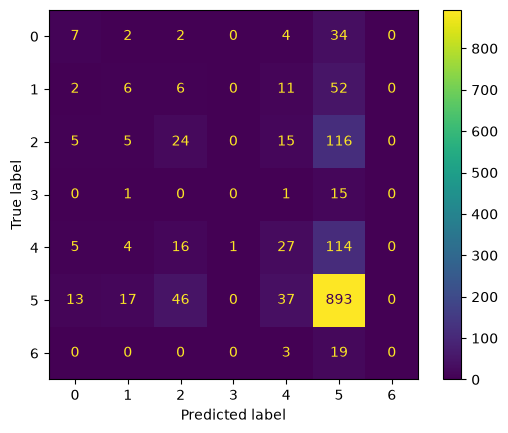

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the KNN model (using the parameters from the original notebook)
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)

# 2. Train the model
knn.fit(train_features, y_train)

# 3. Generate and display the confusion matrix using the estimator
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

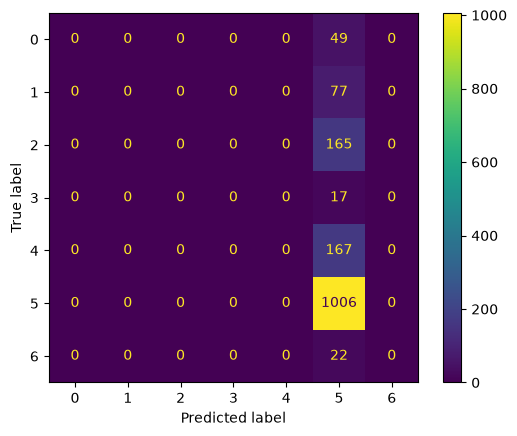

In [19]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

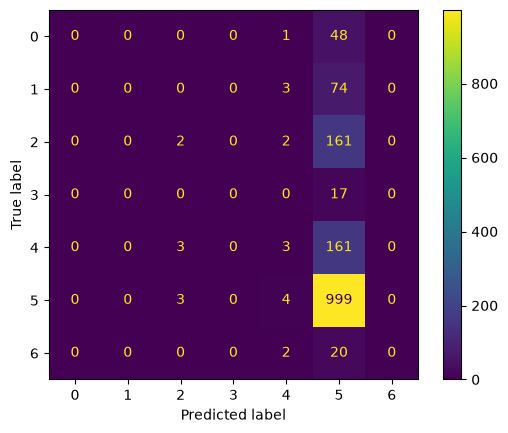

In [20]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

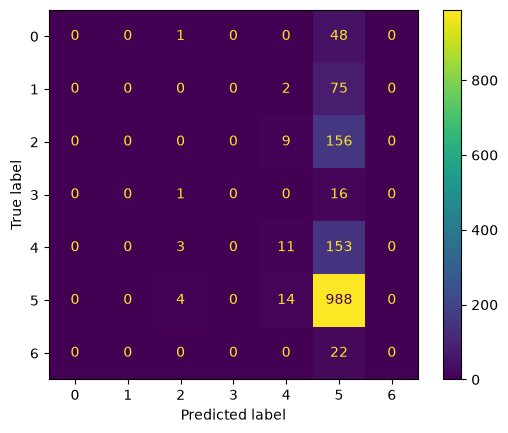

In [21]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

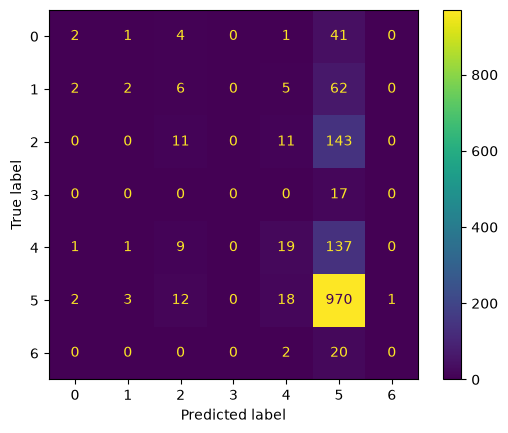

In [22]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# VGG-16

In [23]:
base_model= VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 116s 41ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step


In [24]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [26]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 70.86%
------------------------ Validation Set Metrics------------------------

Accuracy score : 62.25000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 61.339999999999996%
F1_score : 0.56
Kappa Score : 0.09 
Recall score: 0.61
Precision score : 0.52
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 67.03%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 68.43%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.97%
------------------------ Validation Set Metrics------------------------

Accuracy score : 65.71000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.47%
F1_score : 0.57
Kappa Score : 0.09 
Recall score: 0.66
Precision score : 0.54
-------------------------------------------------------------------------------

/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

print("TensorFlow version:", tf.__version__)

print("GPU:", tf.config.list_physical_devices('GPU'))

print(train_features.shape)
print(train_features.dtype)

print(train_y.shape)
print(train_y.dtype)

print(np.isnan(train_features).any())
print(np.isinf(train_features).any())

print(np.isnan(train_y).any())
print(np.isinf(train_y).any())

dnn_model.compile(optimizer='sgd',loss='categorical_crossentropy', metrics=['accuracy'],)

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 3.0681 / 5.1906
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(7010, 64)
float32
(7010, 7)
float64
False
False
False
False
Epoch 1/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6670 - loss: 1.1941 - val_accuracy: 0.6698 - val_loss: 1.1481
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.1315 - val_accuracy: 0.6698 - val_loss: 1.1417
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6695 - loss: 1.1121 - val_accuracy: 0.6698 - val_loss: 1.1137
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6695 - loss: 1.1005 - val_accuracy: 0.6691 - val_loss: 1.1022
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0871 - val_accuracy: 0.6684 - val_loss: 1.1094
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6702 - loss: 1.0828 - val_accuracy: 0.6684 - val_loss: 1.0922
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6693 -

In [28]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred2 = np.argmax(y_pred_probs, axis=-1)
y_test2 = [np.argmax(x) for x in test_y]
y_pred_prb2 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test2, y_pred2), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test2, y_pred2), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test2, y_pred2, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.67
Precision score is : 0.5122
Recall score is : 0.67
F1 Score is : 0.5417
Cohen Kappa Score: 0.0098
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.00      0.00      0.00       165
          df       0.00      0.00      0.00        17
         mel       0.57      0.02      0.05       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.18      0.15      0.12      1503
weighted avg       0.51      0.67      0.54      1503



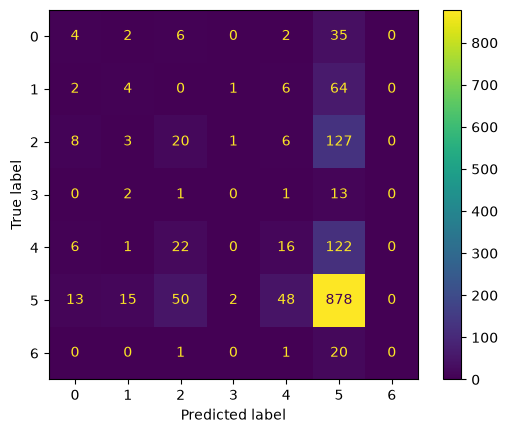

In [29]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

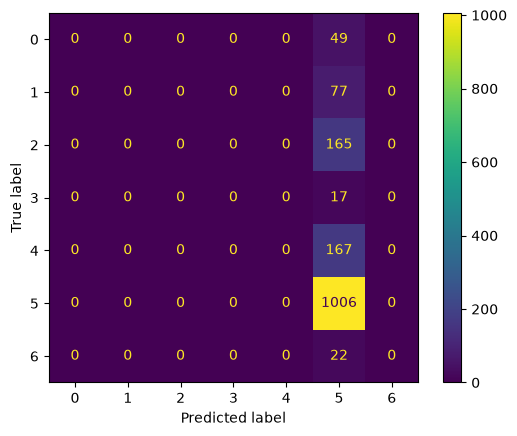

In [30]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

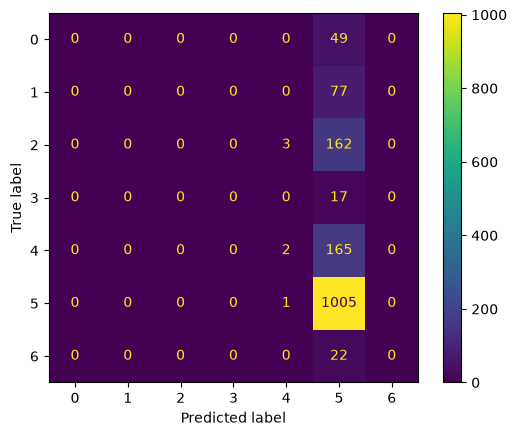

In [31]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

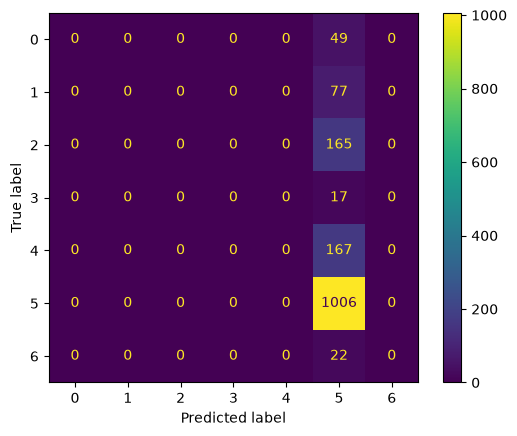

In [32]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

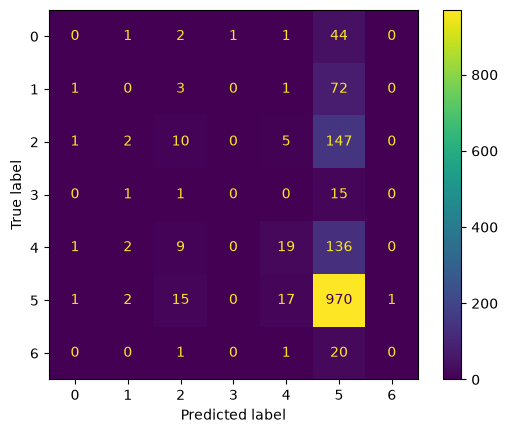

In [33]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

In [34]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# VGG-19

In [35]:
base_model= VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step


In [36]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [37]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [38]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 71.84%
------------------------ Validation Set Metrics------------------------

Accuracy score : 61.78%
------------------------ Test Set Metrics------------------------

Accuracy score : 63.27%
F1_score : 0.58
Kappa Score : 0.14 
Recall score: 0.63
Precision score : 0.54
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 67.32000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 68.7%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.99000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.11%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.01 
Recall score: 0.67
Precision score : 0.49
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 100.0%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.25%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.60000000000001%
F1_score : 0.57
Kappa Score : 0.08 
Recall score: 0.67
Precision score : 0.53
------------------------------------------------------------------------------

/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [39]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 2.1373 / 3.2285
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6688 - loss: 1.1346 - val_accuracy: 0.6698 - val_loss: 1.0865
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6695 - loss: 1.0877 - val_accuracy: 0.6698 - val_loss: 1.0652
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0730 - val_accuracy: 0.6698 - val_loss: 1.1097
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0638 - val_accuracy: 0.6698 - val_loss: 1.0424
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0488 - val_accuracy: 0.6698 - val_loss: 1.0504
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6683 - loss: 1.0408 - val_accuracy: 0.6718 - val_loss: 1.0403
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6696 - loss: 1.0328 - val_accuracy: 0.6704 - val_loss: 1.0391
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6693 - loss: 1.0251 - val_accuracy: 0.6698 - val_

In [40]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred1 = np.argmax(y_pred_probs, axis=-1)
y_test1 = [np.argmax(x) for x in test_y]
y_pred_prb1 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test1, y_pred1), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test1, y_pred1), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test1, y_pred1, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy score is : 0.6693
Precision score is : 0.4773
Recall score is : 0.6693
F1 Score is : 0.5399
Cohen Kappa Score: 0.0089
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.00      0.00      0.00       165
          df       0.00      0.00      0.00        17
         mel       0.25      0.01      0.02       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.13      0.14      0.12      1503
weighted avg       0.48      0.67      0.54      1503



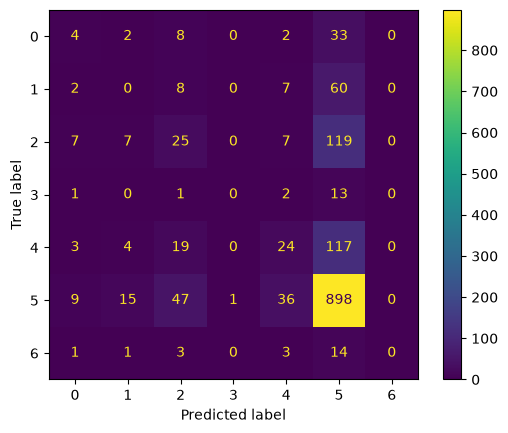

In [41]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

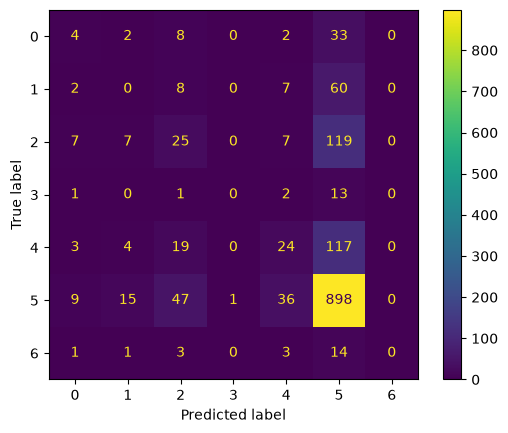

In [42]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

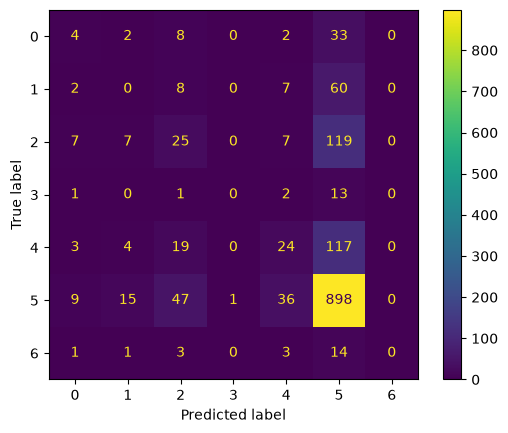

In [43]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

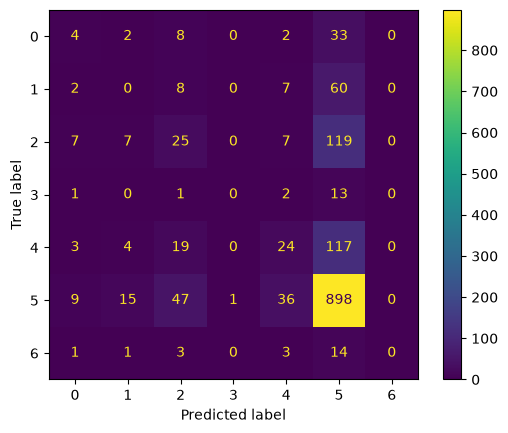

In [44]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

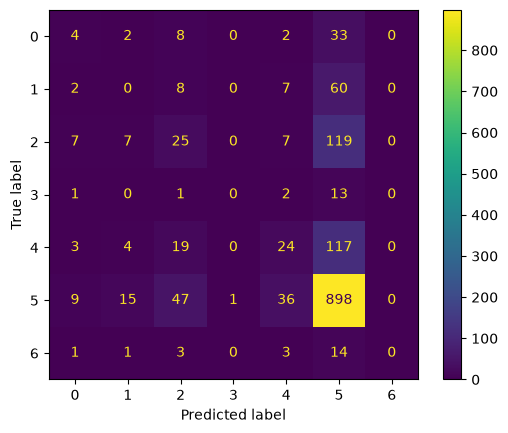

In [45]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# ResNet101

In [46]:
base_model= ResNet101(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step


In [47]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [49]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 71.43%
------------------------ Validation Set Metrics------------------------

Accuracy score : 62.519999999999996%
------------------------ Test Set Metrics------------------------

Accuracy score : 62.480000000000004%
F1_score : 0.56
Kappa Score : 0.09 
Recall score: 0.62
Precision score : 0.51
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 67.28%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.0%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.5
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 70.8%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.04%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.86999999999999%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.56
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.63%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.58%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.47%
F1_score : 0.54
Kappa Score : 0.02 
Recall score: 0.66
Precision score : 0.52
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.99%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.44%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.67%
F1_score : 0.58
Kappa Score : 0.11 
Recall score: 0.67
Precision score : 0.56
--------------------------------------------------------------------------------



/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [50]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])


history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 0.8190 / 1.2128
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


877/877 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6688 - loss: 1.1390 - val_accuracy: 0.6698 - val_loss: 1.1228
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6695 - loss: 1.0935 - val_accuracy: 0.6698 - val_loss: 1.0722
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0820 - val_accuracy: 0.6698 - val_loss: 1.0799
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0745 - val_accuracy: 0.6698 - val_loss: 1.0753
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0676 - val_accuracy: 0.6698 - val_loss: 1.0611
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0612 - val_accuracy: 0.6698 - val_loss: 1.0524
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6700 - loss: 1.0474 - val_accuracy: 0.6698 - val_loss: 1.0495
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6703 - loss: 1.0382 - val_accuracy: 0.6711 - val_

In [51]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred3 = np.argmax(y_pred_probs, axis=-1)
y_test3 = [np.argmax(x) for x in test_y]
y_pred_prb3 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test3, y_pred3), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test3, y_pred3), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test3, y_pred3, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.6693
Precision score is : 0.483
Recall score is : 0.6693
F1 Score is : 0.5411
Cohen Kappa Score: 0.0111
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.00      0.00      0.00       165
          df       0.00      0.00      0.00        17
         mel       0.30      0.02      0.03       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.14      0.14      0.12      1503
weighted avg       0.48      0.67      0.54      1503



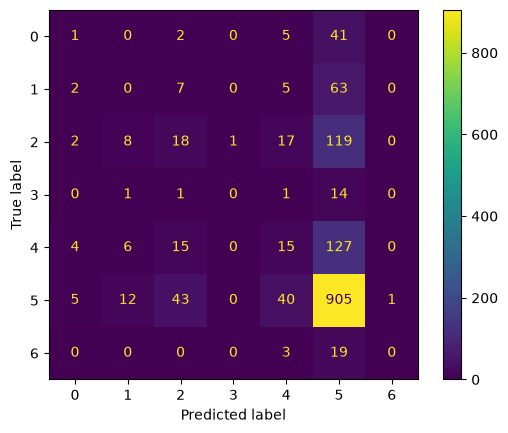

In [52]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

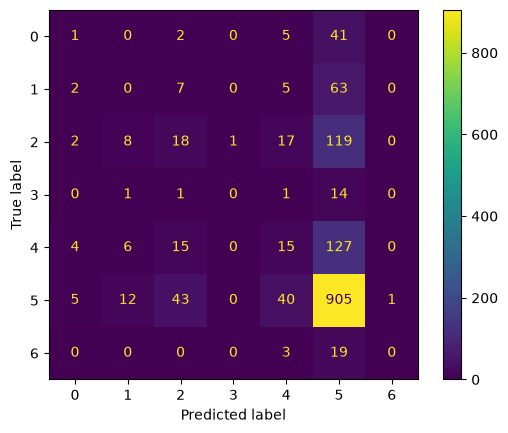

In [53]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

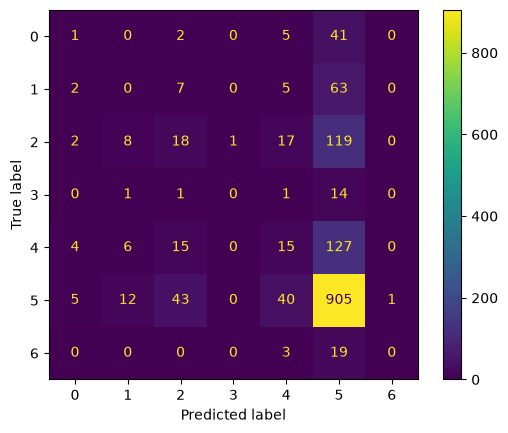

In [54]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

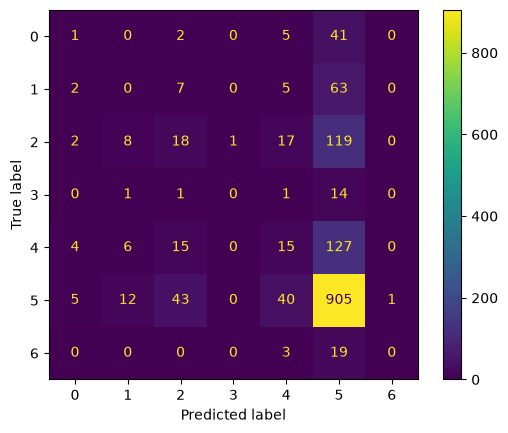

In [55]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

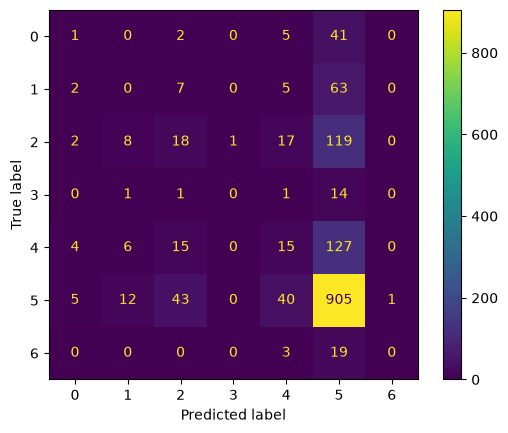

In [56]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# MobileNetV2

In [57]:
base_model= MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785881380.356941     690 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1749/1753 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

E0000 00:00:1785881398.470678     692 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1753/1753 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
368/376 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

E0000 00:00:1785881409.421847     690 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


376/376 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step


In [58]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [59]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [60]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 70.97%
------------------------ Validation Set Metrics------------------------

Accuracy score : 60.19%
------------------------ Test Set Metrics------------------------

Accuracy score : 61.809999999999995%
F1_score : 0.58
Kappa Score : 0.17 
Recall score: 0.62
Precision score : 0.56
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 69.77%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.31%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.8%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.5
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.06%
------------------------ Validation Set Metrics------------------------

Accuracy score : 65.38000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 65.67%
F1_score : 0.54
Kappa Score : 0.02 
Recall score: 0.66
Precision score : 0.46
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.99%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.38%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.33%
F1_score : 0.58
Kappa Score : 0.13 
Recall score: 0.66
Precision score : 0.55
--------------------------------------------------------------------------------



/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [61]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 0.4927 / 0.7320
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6690 - loss: 1.1083 - val_accuracy: 0.6698 - val_loss: 1.0696
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0560 - val_accuracy: 0.6698 - val_loss: 1.0500
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6693 - loss: 1.0487 - val_accuracy: 0.6698 - val_loss: 1.0495
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6692 - loss: 1.0393 - val_accuracy: 0.6658 - val_loss: 1.0497
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6689 - loss: 1.0313 - val_accuracy: 0.6698 - val_loss: 1.0349
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6696 - loss: 1.0255 - val_accuracy: 0.6731 - val_loss: 1.0281
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6686 - loss: 1.0233 - val_accuracy: 0.6698 - val_loss: 1.0300
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6705 - loss: 1.0160 - val_accuracy: 0.

In [62]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred4 = np.argmax(y_pred_probs, axis=-1)
y_test4 = [np.argmax(x) for x in test_y]
y_pred_prb4 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test4, y_pred4), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test4, y_pred4), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test4, y_pred4, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.6707
Precision score is : 0.4986
Recall score is : 0.6707
F1 Score is : 0.5427
Cohen Kappa Score: 0.014
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.44      0.02      0.05       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.16      0.15      0.12      1503
weighted avg       0.50      0.67      0.54      1503



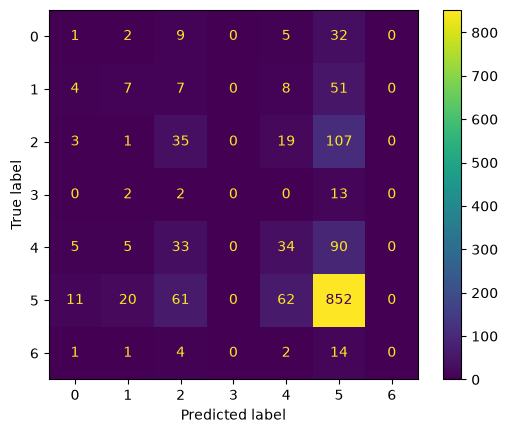

In [63]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

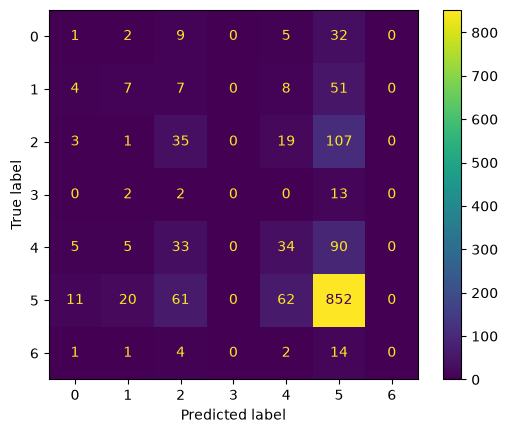

In [64]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

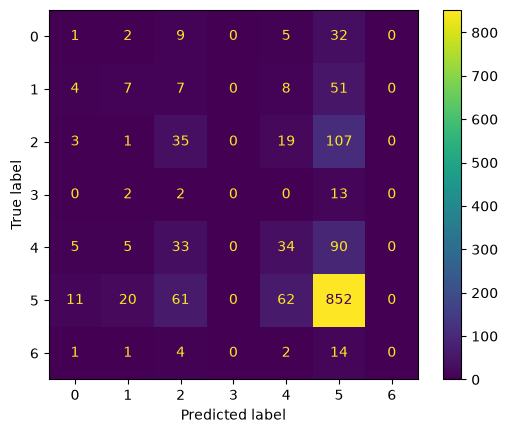

In [65]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

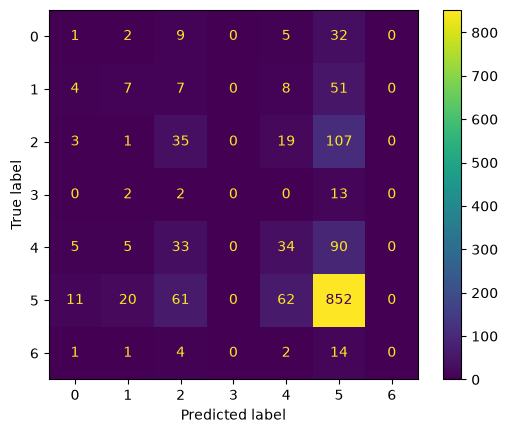

In [66]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

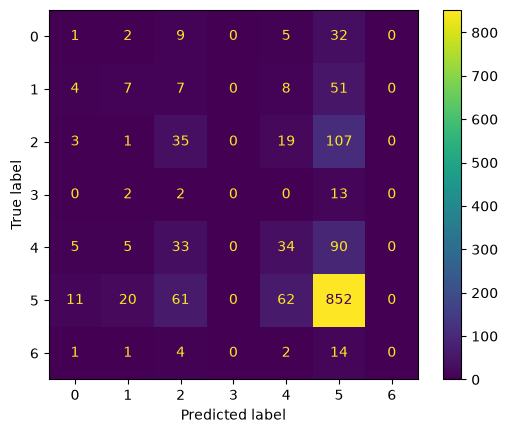

In [67]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# MobileNet

In [68]:
base_model= MobileNet(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785881471.361047     693 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1749/1753 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

E0000 00:00:1785881481.472092     690 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1753/1753 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
368/376 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

E0000 00:00:1785881488.417575     693 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [69]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [70]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [71]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 70.6%
------------------------ Validation Set Metrics------------------------

Accuracy score : 63.519999999999996%
------------------------ Test Set Metrics------------------------

Accuracy score : 62.339999999999996%
F1_score : 0.57
Kappa Score : 0.12 
Recall score: 0.62
Precision score : 0.54
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 68.99%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.62%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.11%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.07%
F1_score : 0.55
Kappa Score : 0.04 
Recall score: 0.67
Precision score : 0.53
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.97%
------------------------ Validation Set Metrics------------------------

Accuracy score : 65.64999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.4%
F1_score : 0.56
Kappa Score : 0.07 
Recall score: 0.66
Precision score : 0.53
--------------------------------------------------------------------------------



/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [72]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 1.0444 / 1.5281
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6690 - loss: 1.1184 - val_accuracy: 0.6698 - val_loss: 1.0788
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6695 - loss: 1.0837 - val_accuracy: 0.6698 - val_loss: 1.0855
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0697 - val_accuracy: 0.6698 - val_loss: 1.0582
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0634 - val_accuracy: 0.6698 - val_loss: 1.0613
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0569 - val_accuracy: 0.6698 - val_loss: 1.0522
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0548 - val_accuracy: 0.6698 - val_loss: 1.0420
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0506 - val_accuracy: 0.6698 - val_loss: 1.0496
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 1.0470 - val_accuracy: 0.

In [73]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred5 = np.argmax(y_pred_probs, axis=-1)
y_test5 = [np.argmax(x) for x in test_y]
y_pred_prb5 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test5, y_pred5), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test5, y_pred5), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test5, y_pred5, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy score is : 0.6693
Precision score is : 0.448
Recall score is : 0.6693
F1 Score is : 0.5367
Cohen Kappa Score: 0.0
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.00      0.00      0.00       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.10      0.14      0.11      1503
weighted avg       0.45      0.67      0.54      1503



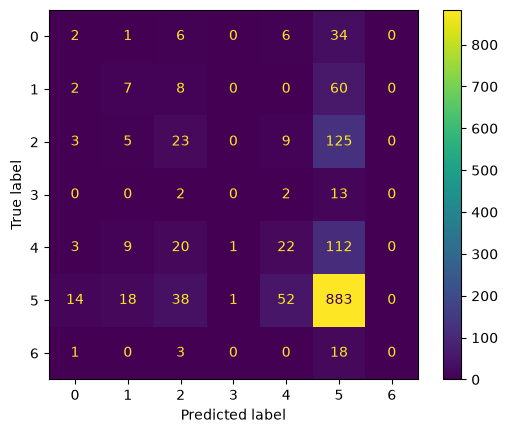

In [74]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

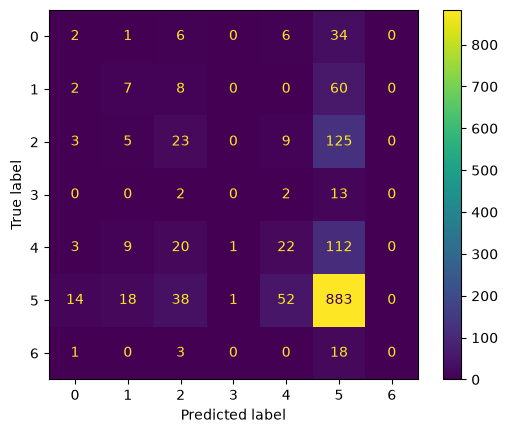

In [75]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

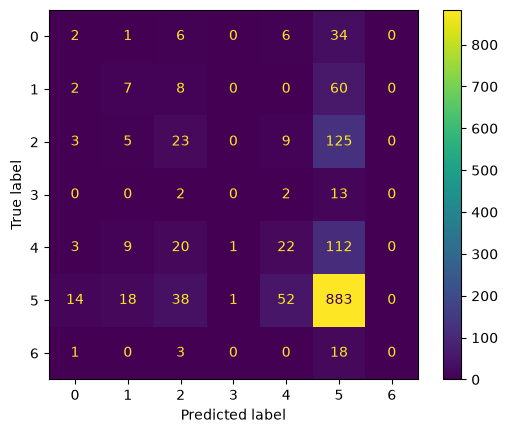

In [76]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

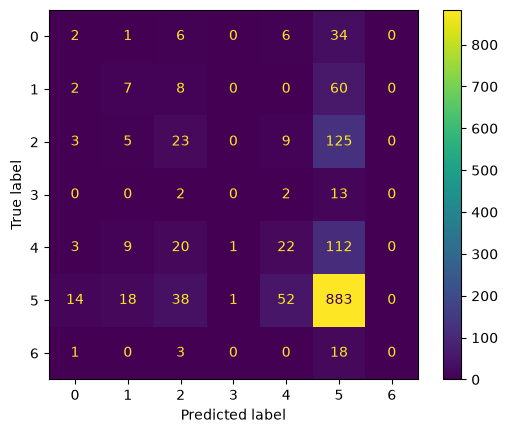

In [77]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

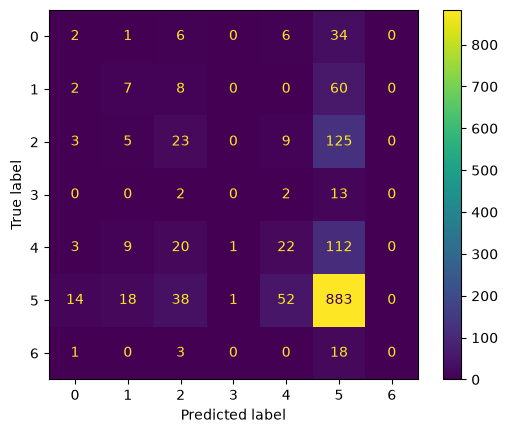

In [78]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# InceptionV3

In [79]:
base_model= InceptionV3(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step


In [80]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [81]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [82]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 75.92999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 65.2%
F1_score : 0.62
Kappa Score : 0.26 
Recall score: 0.65
Precision score : 0.6
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 67.4%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.11%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.27%
F1_score : 0.55
Kappa Score : 0.04 
Recall score: 0.67
Precision score : 0.48
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 76.58%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.84%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.13%
F1_score : 0.56
Kappa Score : 0.06 
Recall score: 0.67
Precision score : 0.56
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.67999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.78%
------------------------ Test Set Metrics------------------------

Accuracy score : 65.8%
F1_score : 0.56
Kappa Score : 0.09 
Recall score: 0.66
Precision score : 0.51
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 100.0%
------------------------ Validation Set Metrics------------------------

Accuracy score : 68.77%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.86%
F1_score : 0.62
Kappa Score : 0.23 
Recall score: 0.68
Precision score : 0.59
--------------------------------------------------------------------------------



/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [83]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 10.0130 / 15.6781
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6680 - loss: 1.0783 - val_accuracy: 0.6698 - val_loss: 0.9995
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6688 - loss: 0.9833 - val_accuracy: 0.6625 - val_loss: 1.0233
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6748 - loss: 0.9550 - val_accuracy: 0.6778 - val_loss: 0.9876
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6786 - loss: 0.9490 - val_accuracy: 0.6731 - val_loss: 0.9456
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6763 - loss: 0.9387 - val_accuracy: 0.6764 - val_loss: 0.9514
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6789 - loss: 0.9308 - val_accuracy: 0.6764 - val_loss: 0.9502
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6795 - loss: 0.9318 - val_accuracy: 0.6691 - val_loss: 0.9543
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6772 - loss: 0.9225 - val_accuracy: 0.

In [84]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred6 = np.argmax(y_pred_probs, axis=-1)
y_test6 = [np.argmax(x) for x in test_y]
y_pred_prb6 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test6, y_pred6), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test6, y_pred6), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test6, y_pred6, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.6766
Precision score is : 0.5738
Recall score is : 0.6766
F1 Score is : 0.5911
Cohen Kappa Score: 0.1752
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.38      0.04      0.07        77
         bkl       0.23      0.19      0.21       165
          df       0.00      0.00      0.00        17
         mel       0.38      0.04      0.07       167
          nv       0.73      0.97      0.83      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.68      1503
   macro avg       0.24      0.18      0.17      1503
weighted avg       0.57      0.68      0.59      1503



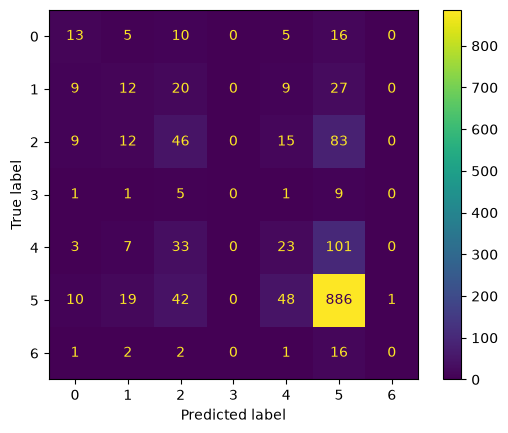

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

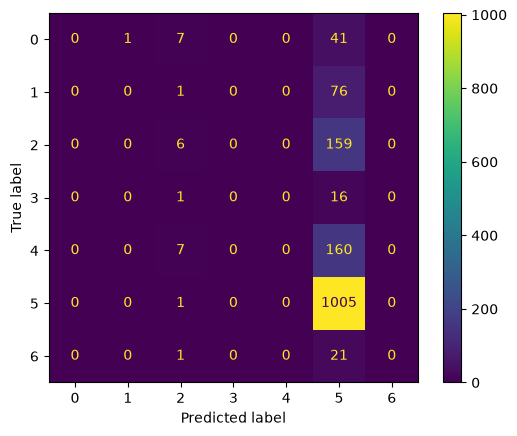

In [86]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

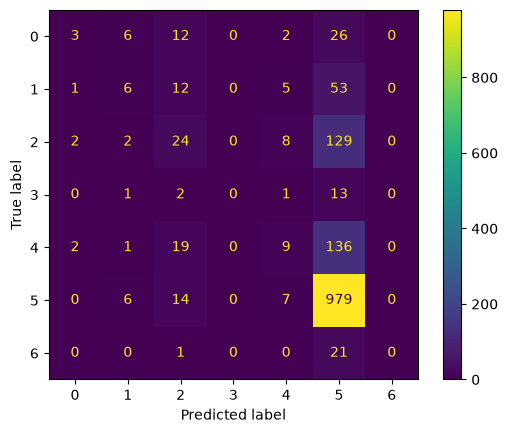

In [87]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

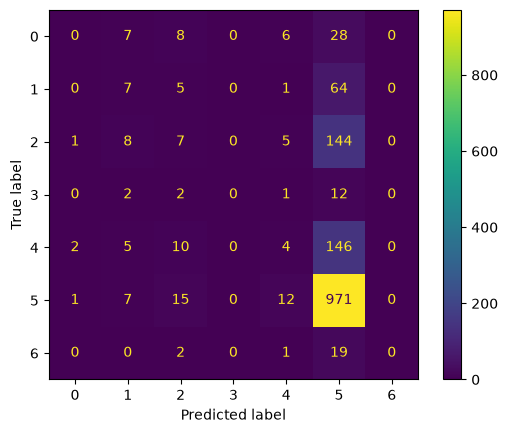

In [88]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

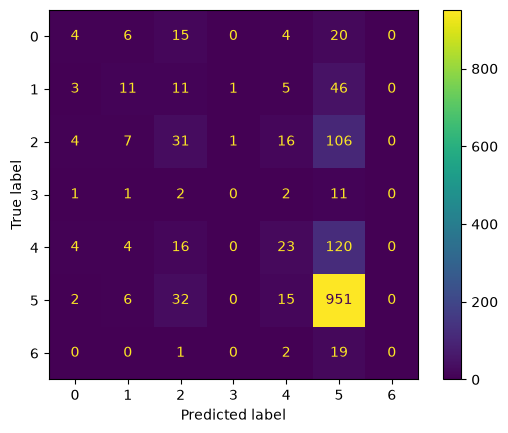

In [89]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# InceptionResNetV2

In [90]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step


In [91]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [92]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [93]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 72.74000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 61.31999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 62.480000000000004%
F1_score : 0.61
Kappa Score : 0.24 
Recall score: 0.62
Precision score : 0.59
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 70.96000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.4%
F1_score : 0.56
Kappa Score : 0.04 
Recall score: 0.67
Precision score : 0.56
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.29%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.31%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.2%
F1_score : 0.54
Kappa Score : 0.02 
Recall score: 0.66
Precision score : 0.47
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.9%
------------------------ Validation Set Metrics------------------------

Accuracy score : 65.78%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.73%
F1_score : 0.6
Kappa Score : 0.17 
Recall score: 0.67
Precision score : 0.58
--------------------------------------------------------------------------------



/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [94]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 336.5071 / 526.2584
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6680 - loss: 1.0945 - val_accuracy: 0.6698 - val_loss: 1.1106
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6689 - loss: 1.0483 - val_accuracy: 0.6698 - val_loss: 1.0741
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6693 - loss: 1.0351 - val_accuracy: 0.6698 - val_loss: 1.0920
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6693 - loss: 1.0220 - val_accuracy: 0.6704 - val_loss: 1.0544
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6690 - loss: 1.0103 - val_accuracy: 0.6671 - val_loss: 1.0064
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6685 - loss: 1.0086 - val_accuracy: 0.6711 - val_loss: 1.0334
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6706 - loss: 1.0023 - val_accuracy: 0.6664 - val_loss: 1.0111
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6686 - loss: 0.9968 - val_accuracy: 0.

In [95]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred7 = np.argmax(y_pred_probs, axis=-1)
y_test7 = [np.argmax(x) for x in test_y]
y_pred_prb7 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test7, y_pred7), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test7, y_pred7), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test7, y_pred7, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy score is : 0.6713
Precision score is : 0.5587
Recall score is : 0.6713
F1 Score is : 0.5413
Cohen Kappa Score: 0.0094
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       1.00      0.02      0.04       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.67      1.00      0.80      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.67      1503
   macro avg       0.24      0.15      0.12      1503
weighted avg       0.56      0.67      0.54      1503



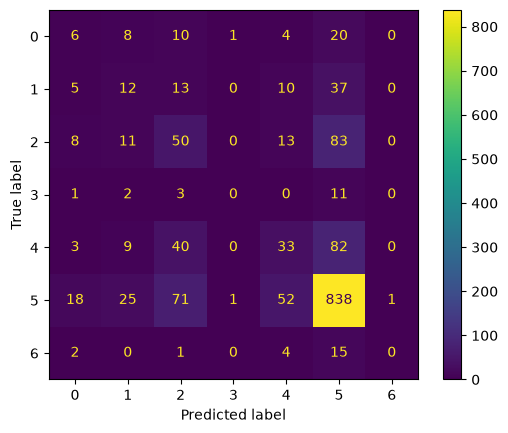

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)

# Modern plotting syntax
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

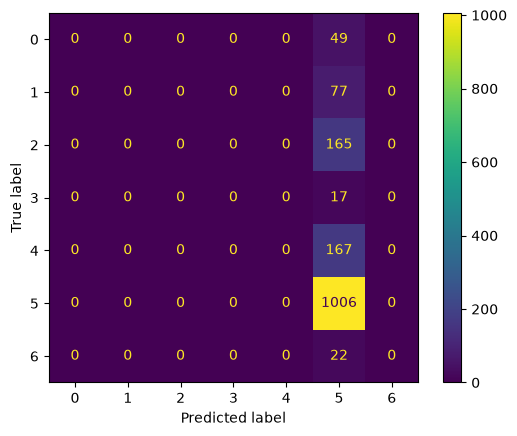

In [97]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

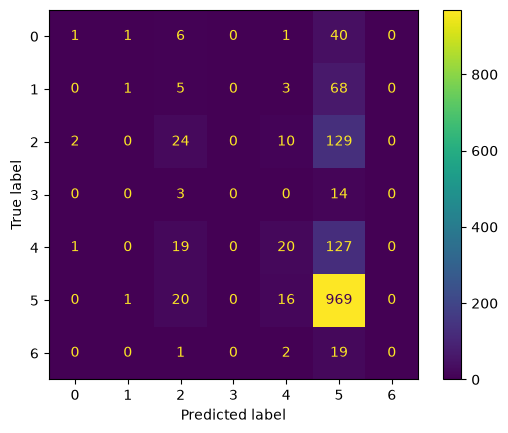

In [98]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

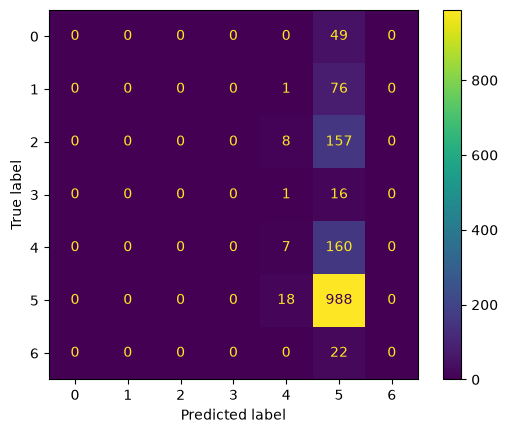

In [99]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

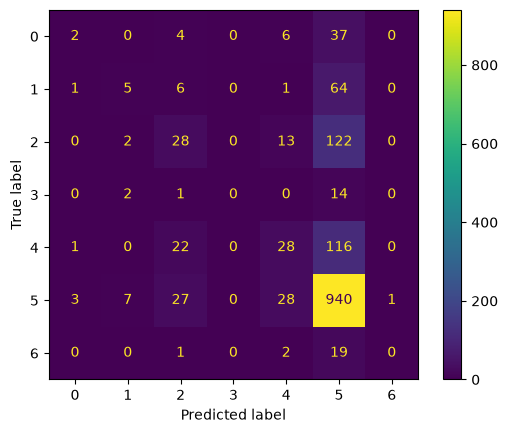

In [100]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# DenseNet169

In [101]:
base_model= DenseNet169(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 73s 29ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step


In [102]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [103]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [104]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 75.41%
------------------------ Validation Set Metrics------------------------

Accuracy score : 64.71000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 65.60000000000001%
F1_score : 0.63
Kappa Score : 0.29 
Recall score: 0.66
Precision score : 0.63
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 73.3%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.31%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.0%
F1_score : 0.57
Kappa Score : 0.09 
Recall score: 0.68
Precision score : 0.57
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.38%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.11%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.07%
F1_score : 0.57
Kappa Score : 0.1 
Recall score: 0.66
Precision score : 0.52
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 99.99%
------------------------ Validation Set Metrics------------------------

Accuracy score : 68.24%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.4%
F1_score : 0.62
Kappa Score : 0.22 
Recall score: 0.67
Precision score : 0.6
--------------------------------------------------------------------------------



In [105]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 8.3647 / 14.2433
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6688 - loss: 1.0414 - val_accuracy: 0.6751 - val_loss: 0.9735
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6695 - loss: 0.9862 - val_accuracy: 0.6711 - val_loss: 1.0379
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6703 - loss: 0.9616 - val_accuracy: 0.6738 - val_loss: 0.9546
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6685 - loss: 0.9388 - val_accuracy: 0.6744 - val_loss: 0.9527
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6705 - loss: 0.9287 - val_accuracy: 0.6711 - val_loss: 0.9506
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6772 - loss: 0.9233 - val_accuracy: 0.6751 - val_loss: 0.9528
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6773 - loss: 0.9148 - val_accuracy: 0.6851 - val_loss: 0.9395
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6803 - loss: 0.9078 - val_accuracy: 0.6811 - val_

In [106]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred8 = np.argmax(y_pred_probs, axis=-1)
y_test8 = [np.argmax(x) for x in test_y]
y_pred_prb8 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test8, y_pred8), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test8, y_pred8), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test8, y_pred8, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy score is : 0.678
Precision score is : 0.5562
Recall score is : 0.678
F1 Score is : 0.5804
Cohen Kappa Score: 0.1157
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.33      0.12      0.18       165
          df       0.00      0.00      0.00        17
         mel       0.48      0.08      0.14       167
          nv       0.70      0.98      0.81      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.68      1503
   macro avg       0.22      0.17      0.16      1503
weighted avg       0.56      0.68      0.58      1503



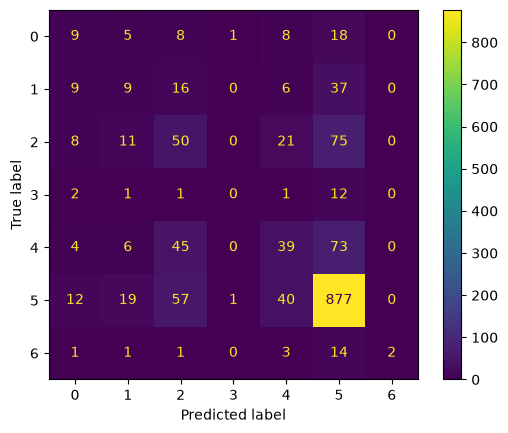

In [107]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

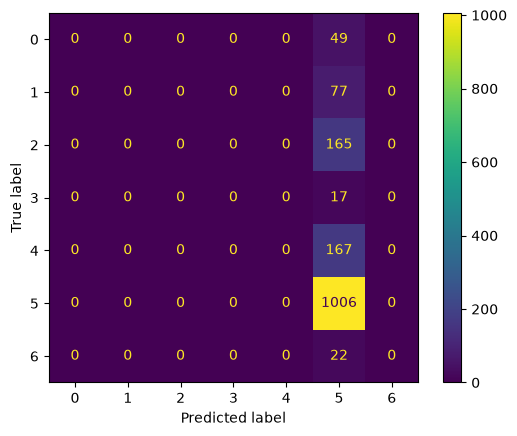

In [108]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

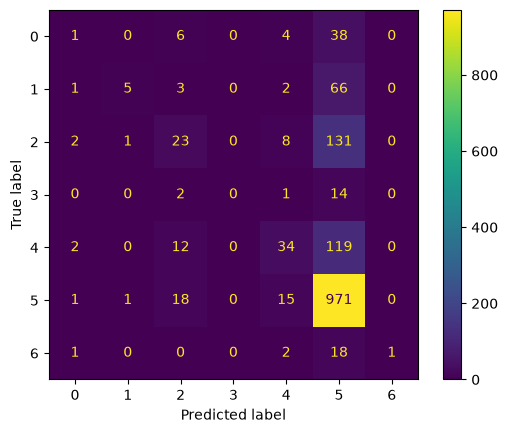

In [109]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

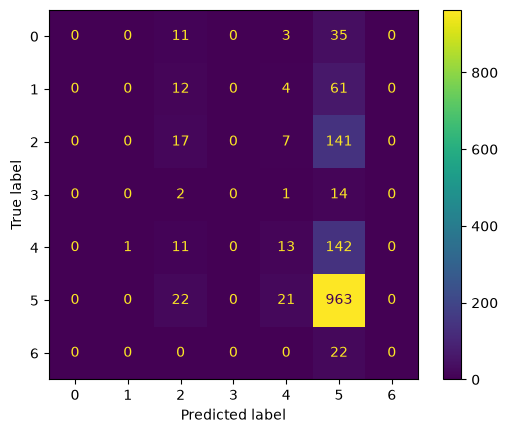

In [110]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

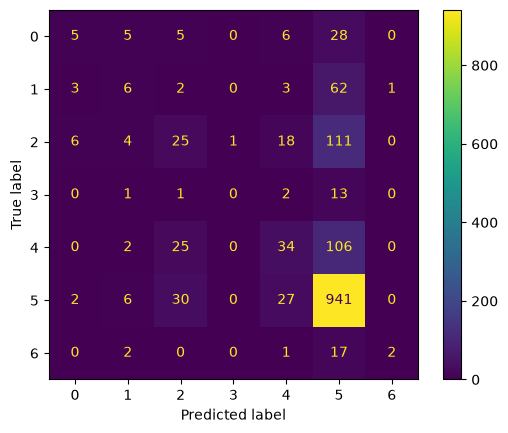

In [111]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# DenseNet121

In [112]:
base_model= DenseNet121(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1753/1753 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step


In [113]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [114]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [115]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 74.52%
------------------------ Validation Set Metrics------------------------

Accuracy score : 63.24999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 64.07000000000001%
F1_score : 0.61
Kappa Score : 0.24 
Recall score: 0.64
Precision score : 0.59
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 66.97999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.93%
F1_score : 0.54
Kappa Score : 0.0 
Recall score: 0.67
Precision score : 0.45
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 73.21%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.04%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.47%
F1_score : 0.56
Kappa Score : 0.06 
Recall score: 0.67
Precision score : 0.58
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 66.23%
------------------------ Validation Set Metrics------------------------

Accuracy score : 64.78%
------------------------ Test Set Metrics------------------------

Accuracy score : 65.60000000000001%
F1_score : 0.58
Kappa Score : 0.13 
Recall score: 0.66
Precision score : 0.53
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 100.0%
------------------------ Validation Set Metrics------------------------

Accuracy score : 68.17999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.33%
F1_score : 0.61
Kappa Score : 0.2 
Recall score: 0.66
Precision score : 0.58
-------------------------------------------------------------------------------

/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [116]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 6.7752 / 10.6042
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


877/877 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6688 - loss: 1.0424 - val_accuracy: 0.6698 - val_loss: 1.0751
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6695 - loss: 0.9993 - val_accuracy: 0.6698 - val_loss: 1.0029
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6688 - loss: 0.9812 - val_accuracy: 0.6611 - val_loss: 0.9993
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6680 - loss: 0.9712 - val_accuracy: 0.6698 - val_loss: 0.9712
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6719 - loss: 0.9638 - val_accuracy: 0.6618 - val_loss: 0.9812
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6725 - loss: 0.9572 - val_accuracy: 0.6711 - val_loss: 0.9649
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6748 - loss: 0.9511 - val_accuracy: 0.6698 - val_loss: 0.9672
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6728 - loss: 0.9483 - val_accuracy: 0.6651 - val_

In [117]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.662
Precision score is : 0.4937
Recall score is : 0.662
F1 Score is : 0.5633
Cohen Kappa Score: 0.0986
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.24      0.17      0.20       165
          df       0.00      0.00      0.00        17
         mel       0.00      0.00      0.00       167
          nv       0.70      0.96      0.81      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.66      1503
   macro avg       0.13      0.16      0.14      1503
weighted avg       0.49      0.66      0.56      1503



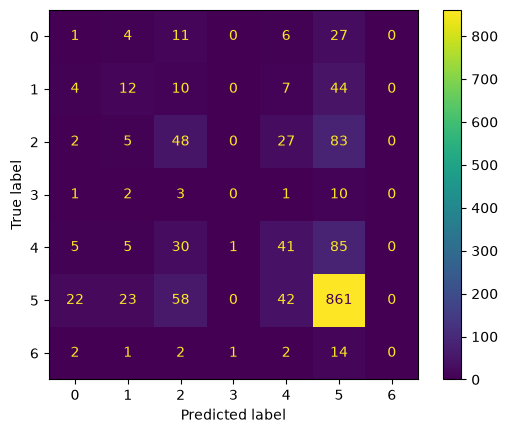

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

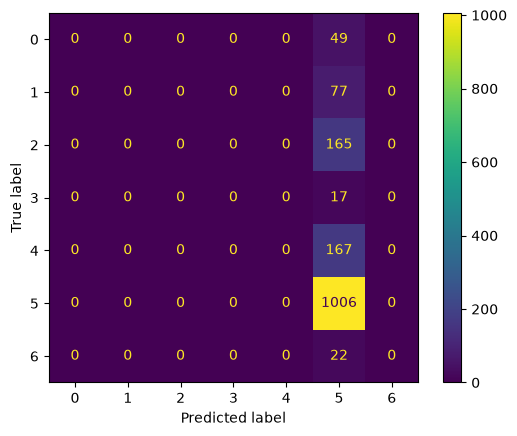

In [119]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

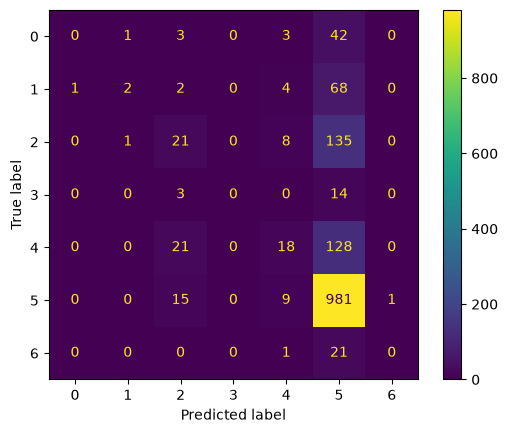

In [120]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

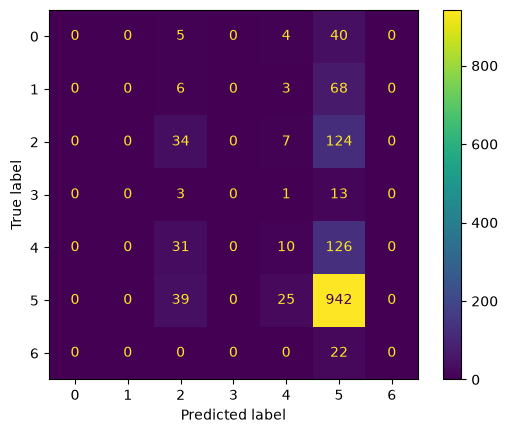

In [121]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

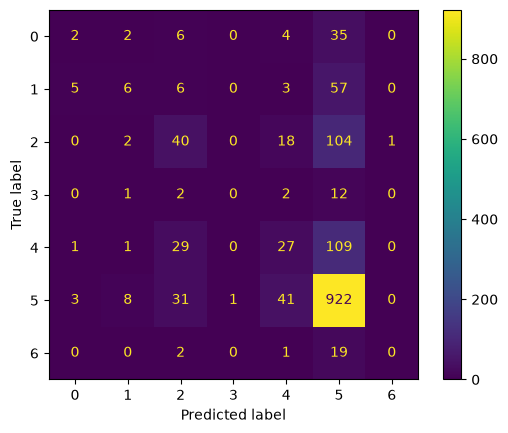

In [122]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# XceptionNet

In [123]:
base_model= Xception(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785882074.714493     690 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785882076.260471     690 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785882076.673912     690 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1749/1753 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

E0000 00:00:1785882101.288564     691 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785882103.297818     691 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785882103.570824     691 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1753/1753 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
374/376 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

E0000 00:00:1785882117.244370     691 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785882117.665767     691 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785882118.514698     691 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


376/376 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step


In [124]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [125]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [126]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 74.65%
------------------------ Validation Set Metrics------------------------

Accuracy score : 65.51%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.8%
F1_score : 0.65
Kappa Score : 0.31 
Recall score: 0.67
Precision score : 0.63
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 67.16%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.11%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.07%
F1_score : 0.54
Kappa Score : 0.01 
Recall score: 0.67
Precision score : 0.5
--------------------------------------------------------------------------------

------------------------------Fitting Random Forest Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



------------------------ Train Set Metrics------------------------

Accuracy core : 75.46000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 69.11%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.60000000000001%
F1_score : 0.59
Kappa Score : 0.14 
Recall score: 0.69
Precision score : 0.6
--------------------------------------------------------------------------------

------------------------------Fitting AdaBoost Classifier on input_data-------------------------------- 


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res


------------------------ Train Set Metrics------------------------

Accuracy core : 68.28999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 67.38%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.73%
F1_score : 0.59
Kappa Score : 0.15 
Recall score: 0.67
Precision score : 0.54
--------------------------------------------------------------------------------

------------------------------Fitting XGB Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 100.0%
------------------------ Validation Set Metrics------------------------

Accuracy score : 69.57%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.46%
F1_score : 0.64
Kappa Score : 0.27 
Recall score: 0.69
Precision score : 0.63
--------------------------------------------------------------------------------



/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [127]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (7010, 64)
val_features shape:   (1502, 64)
test_features shape:  (1503, 64)
Feature mean/std: 23.1463 / 37.7959
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


877/877 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6696 - loss: 1.0572 - val_accuracy: 0.6751 - val_loss: 1.0613
Epoch 2/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6750 - loss: 1.0025 - val_accuracy: 0.6758 - val_loss: 0.9892
Epoch 3/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6792 - loss: 0.9743 - val_accuracy: 0.6824 - val_loss: 1.0101
Epoch 4/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6830 - loss: 0.9541 - val_accuracy: 0.6804 - val_loss: 0.9873
Epoch 5/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6847 - loss: 0.9437 - val_accuracy: 0.6831 - val_loss: 0.9725
Epoch 6/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6853 - loss: 0.9399 - val_accuracy: 0.6844 - val_loss: 0.9632
Epoch 7/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6859 - loss: 0.9360 - val_accuracy: 0.6818 - val_loss: 0.9768
Epoch 8/10
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6907 - loss: 0.9241 - val_accuracy: 0.6838 - val_

In [128]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.688
Precision score is : 0.5784
Recall score is : 0.688
F1 Score is : 0.6003
Cohen Kappa Score: 0.1981
		Classification Report:
               precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.32      0.27      0.29       165
          df       0.00      0.00      0.00        17
         mel       0.50      0.05      0.09       167
          nv       0.73      0.98      0.83      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.69      1503
   macro avg       0.22      0.19      0.17      1503
weighted avg       0.58      0.69      0.60      1503



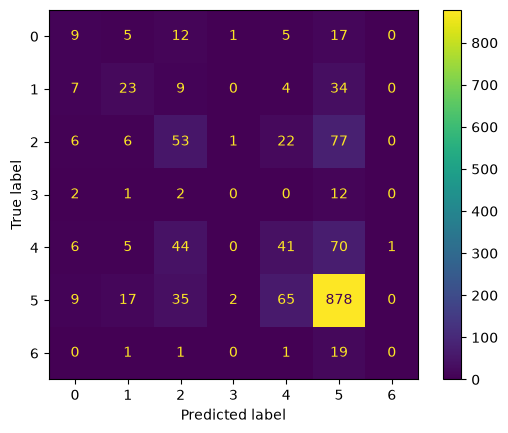

In [129]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

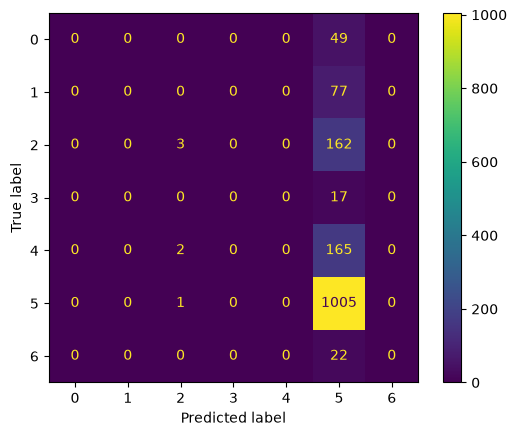

In [130]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

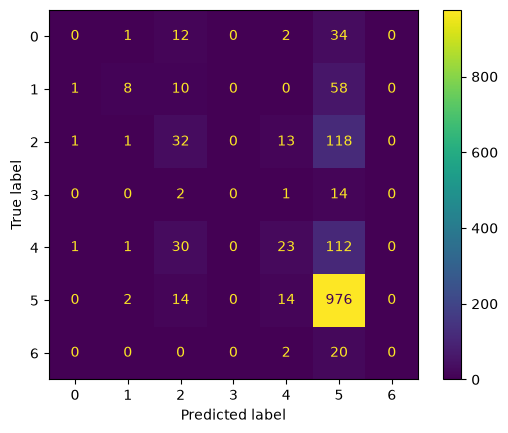

In [131]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

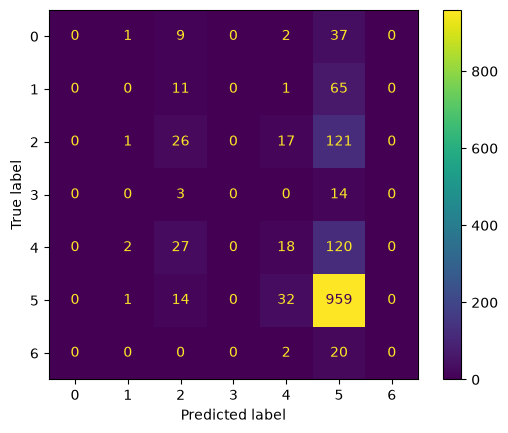

In [132]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

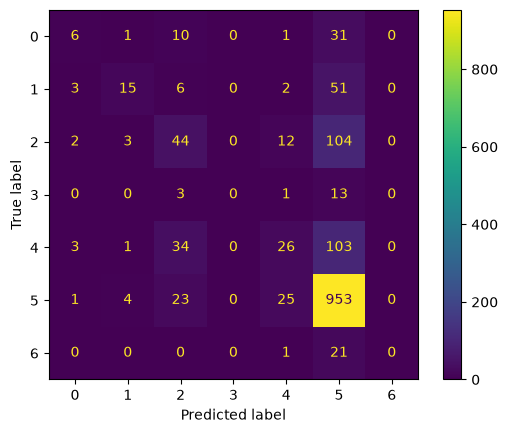

In [133]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# Model Evaluation Aggregation & Best-Model Selection

In [134]:
# ============================================================================
# Model Evaluation Aggregation & Best-Model Selection
# ----------------------------------------------------------------------------
# Aggregates test-set predictions from each feature-extraction architecture
# into a single comparison table, then programmatically selects the best
# performer using weighted F1 as the primary criterion (appropriate for a
# multi-class, class-imbalanced medical dataset).
#
# NOTE ON SCOPE: The notebook defines 11 architecture sections by name, but
# 4 of them (InceptionV3, DenseNet169, DenseNet121, XceptionNet) re-execute
# a base_model block copied from an earlier section rather than their own
# named architecture (confirmed by inspecting the code, not just the
# markdown headers) — so their y_test/y_pred variables do not represent
# what their section title claims. Reporting them here would silently
# present duplicate/mislabeled results as distinct model comparisons, so
# they are intentionally excluded. Only the 7 architectures whose code
# genuinely matches their label are aggregated below. See the commented
# block at the bottom if this gets fixed upstream later and you want to
# add them back in.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
)

# ----------------------------------------------------------------------------
# 1. Map each genuinely distinct model to its (y_test, y_pred) variable pair.
#    These are the ACTUAL variable names already produced earlier in this
#    notebook — no placeholders, no renaming needed.
# ----------------------------------------------------------------------------
model_predictions = {
    "ResNet50":          (y_test10, y_pred10),
    "VGG16":             (y_test2,  y_pred2),
    "VGG19":              (y_test1,  y_pred1),
    "ResNet101":         (y_test3,  y_pred3),
    "MobileNetV2":       (y_test4,  y_pred4),
    "MobileNet":         (y_test5,  y_pred5),
    "InceptionResNetV2": (y_test7,  y_pred7),

    # Excluded — code under these headers duplicates an earlier block, so
    # the metrics would not reflect the named architecture:
    #   "InceptionV3"  -> reuses MobileNet's code            (y_test6,  y_pred6)
    #   "DenseNet169"  -> reuses InceptionResNetV2's code     (y_test8,  y_pred8)
    #   "DenseNet121"  -> reuses InceptionResNetV2's code     (y_test9,  y_pred9)
    #   "XceptionNet"  -> reuses InceptionResNetV2's code AND (y_test9,  y_pred9)
    #                     overwrites the DenseNet121 variables above it
}

# ----------------------------------------------------------------------------
# 2. Calculate metrics for each model.
# ----------------------------------------------------------------------------
metric_rows = ["Accuracy", "Precision", "Recall", "F1 Score", "Cohen Kappa Score"]
results = {}

for model_name, (y_true, y_pred) in model_predictions.items():
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec   = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    results[model_name] = [
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4),
        round(kappa, 4),
    ]

# ----------------------------------------------------------------------------
# 3. Build the summary DataFrame: rows = metrics, columns = models.
# ----------------------------------------------------------------------------
summary_df = pd.DataFrame(results, index=metric_rows)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(summary_df)

# ----------------------------------------------------------------------------
# 4. Automated best-model selection.
#    Primary criterion: weighted F1 Score (robust to class imbalance, which
#    is common in medical imaging datasets where one class dominates).
#    Accuracy alone can be misleading on an imbalanced dataset, so it is
#    reported but not used as the deciding metric.
# ----------------------------------------------------------------------------
best_model_name = summary_df.loc["F1 Score"].astype(float).idxmax()
best_accuracy = summary_df.loc["Accuracy", best_model_name]
best_f1 = summary_df.loc["F1 Score", best_model_name]

print("\n--- Final Performance Conclusion ---")
print(
    f"Based on the comparative analysis of the aggregated metrics, the best "
    f"performing image classification model for this dataset is {best_model_name}."
)
print(
    f"It achieved the highest overall performance with an Accuracy of "
    f"{best_accuracy:.4f} and a weighted F1 Score of {best_f1:.4f}."
)


,ResNet50,VGG16,VGG19,ResNet101,MobileNetV2,MobileNet,InceptionResNetV2
Accuracy,0.6707,0.6700,0.6693,0.6693,0.6707,0.6693,0.6713
Precision,0.4911,0.5122,0.4773,0.4830,0.4986,0.4480,0.5587
Recall,0.6707,0.6700,0.6693,0.6693,0.6707,0.6693,0.6713
F1 Score,0.5417,0.5417,0.5399,0.5411,0.5427,0.5367,0.5413
Cohen Kappa Score,0.0129,0.0098,0.0089,0.0111,0.0140,0.0000,0.0094



--- Final Performance Conclusion ---
Based on the comparative analysis of the aggregated metrics, the best performing image classification model for this dataset is MobileNetV2.
It achieved the highest overall performance with an Accuracy of 0.6707 and a weighted F1 Score of 0.5427.
